# Library Imports & Global Settings

Imports required libraries for survival analysis, data manipulation, and visualization. Sets global parameters including job code tracking count and prestige calculation flag.

In [2]:
# (Cell 02) Library Imports & Global Settings
import lifelines
print(lifelines.__version__)
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from lifelines import datasets, CoxPHFitter
from lifelines.utils import to_long_format
import warnings
warnings.filterwarnings('ignore')

import sys
from IPython.display import IFrame
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))


# Import NetworkX for hierarchy analysis
import networkx as nx
from collections import defaultdict, deque
from typing import List, Set, Dict, Tuple, Optional, Union

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")
print("Note: plot_partial_effects_on_outcome is a method of CoxPHFitter, not a separate import")

# Set job_codes to track for visualization
job_code_track_count = 5
print("Job code track count:", job_code_track_count)

# Set the Boolean variable prestige_calc to decide whether or not to do prestige calculations
prestige_calc = True


0.30.0


Libraries imported successfully!
Note: plot_partial_effects_on_outcome is a method of CoxPHFitter, not a separate import
Job code track count: 5


In [3]:
# Load the UIC hierarchy data
df = pd.read_csv('508_1.csv')

print(f"📊 Loaded hierarchy data: {len(df):,} rows")
print(f"📋 Columns: {list(df.columns)}")
print(f"📈 Unique UICs: {df['UIC'].nunique():,}")
print(f"🏢 Top-level UICs (no parent): {df[df['PARENTUIC'].isna()]['UIC'].nunique()}")

df.head()

📊 Loaded hierarchy data: 18,287 rows
📋 Columns: ['FY', 'UIC', 'PARENTUIC', 'SIMPLENAME', 'UICTYPE', 'DOCTPE', 'DRRSANAME', 'CMD', 'COMPO', 'UTC', 'SRC', 'SRC2', 'SRC5', 'SRC9', 'LOCNM', 'CITY', 'STATE', 'COUNTRY', 'STACO', 'TPSN', 'BRANCH', 'DP99', 'UICPATH', 'NAMEPATH', 'DOWNLOADDATE', 'VALIDPATH']
📈 Unique UICs: 18,284
🏢 Top-level UICs (no parent): 1


,FY,UIC,PARENTUIC,SIMPLENAME,UICTYPE,DOCTPE,DRRSANAME,CMD,COMPO,UTC,...,STATE,COUNTRY,STACO,TPSN,BRANCH,DP99,UICPATH,NAMEPATH,DOWNLOADDATE,VALIDPATH
0,2018,WDARFF,NaN,DA,TITULAR,ROLLUP,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,>WDARFF,>DA,16-Jul-2025,Yes
1,2018,W0ZUFF,WDARFF,HQDA,TITULAR,ROLLUP,W0ZU HEADQUARTERS U.S.ARMY,DF,1.0,CTUTL,...,NaN,NaN,NaN,NaN,NaN,NaN,>WDARFF>W0ZUFF,>DA>HQDA,16-Jul-2025,Yes
2,2018,W00EFF,W0ZUFF,OfcSecArmy,TITULAR,ROLLUP,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,>WDARFF>W0ZUFF>W00EFF,>DA>HQDA>OfcSecArmy,16-Jul-2025,Yes
3,2018,W00EAA,W00EFF,IOSA,PARENT,TDA,W00E IMMEDIATE OFC SEC ARMY,SA,1.0,CTDAU,...,VA,USA,51978,8H100,NaN,GFCC,>WDARFF>W0ZUFF>W00EFF>W00EAA,>DA>HQDA>OfcSecArmy>IOSA,16-Jul-2025,Yes
4,2018,W00FAA,W00EFF,ODUSA,PARENT,TDA,W00F OFC DEP UNDER SEC ARMY,SA,1.0,CTDAU,...,VA,USA,51978,8H100,NaN,GFCC,>WDARFF>W0ZUFF>W00EFF>W00FAA,>DA>HQDA>OfcSecArmy>ODUSA,16-Jul-2025,Yes


In [4]:
# UIC Hierarchy Analysis Functions
def find_subordinate_uics_recursive(df: pd.DataFrame, 
                                   top_uics: List[str], 
                                   uic_col: str = 'UIC', 
                                   parent_col: str = 'PARENTUIC',
                                   include_top: bool = True,
                                   max_depth: Optional[int] = None) -> Dict[str, Set[str]]:
    """
    Recursively find all subordinate UICs for a given list of top-level UICs.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing UIC hierarchy data
    top_uics : List[str]
        List of top-level UICs to start the search from
    uic_col : str, default 'UIC'
        Column name containing the unit identification codes
    parent_col : str, default 'PARENTUIC'
        Column name containing the parent/superior UIC for each unit
    include_top : bool, default True
        Whether to include the top-level UICs in the results
    max_depth : Optional[int], default None
        Maximum depth to search (None for unlimited depth)
        
    Returns:
    --------
    Dict[str, Set[str]]
        Dictionary where keys are top-level UICs and values are sets of all subordinate UICs
    """
    
    # Validate inputs
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame")
    
    if uic_col not in df.columns:
        raise ValueError(f"Column '{uic_col}' not found in DataFrame")
    
    if parent_col not in df.columns:
        raise ValueError(f"Column '{parent_col}' not found in DataFrame")
    
    if not isinstance(top_uics, (list, tuple, set)):
        top_uics = [top_uics]
    
    # Create lookup dictionary for faster searching
    # Group by parent UIC to get all direct subordinates
    hierarchy_dict = defaultdict(set)
    
    # Remove rows with null UICs or parent UICs for cleaner processing
    clean_df = df.dropna(subset=[uic_col, parent_col])
    
    # Build the hierarchy dictionary
    for _, row in clean_df.iterrows():
        parent = row[parent_col]
        child = row[uic_col]
        if pd.notna(parent) and pd.notna(child):
            hierarchy_dict[parent].add(child)
    
    print(f"📊 Built hierarchy dictionary with {len(hierarchy_dict)} parent UICs")
    
    # Results dictionary
    results = {}
    
    # Process each top-level UIC
    for top_uic in top_uics:
        subordinates = set()
        
        if include_top:
            subordinates.add(top_uic)
        
        # Use BFS to find all subordinates
        queue = deque([(top_uic, 0)])  # (uic, depth)
        visited = set()
        
        while queue:
            current_uic, depth = queue.popleft()
            
            # Skip if we've already processed this UIC
            if current_uic in visited:
                continue
                
            visited.add(current_uic)
            
            # Check depth limit
            if max_depth is not None and depth >= max_depth:
                continue
            
            # Get direct subordinates
            direct_subordinates = hierarchy_dict.get(current_uic, set())
            
            # Add them to results and queue
            for sub_uic in direct_subordinates:
                subordinates.add(sub_uic)
                queue.append((sub_uic, depth + 1))
        
        results[top_uic] = subordinates
        print(f"🎯 Found {len(subordinates)} total subordinates for {top_uic}")
    
    return results

print("✅ UIC hierarchy function loaded!")

✅ UIC hierarchy function loaded!


In [40]:
# NetworkX Graph Creation Function
def create_uic_hierarchy_network(df: pd.DataFrame,
                                top_uics: List[str],
                                uic_col: str = 'UIC',
                                parent_col: str = 'PARENTUIC',
                                include_metadata: bool = True,
                                metadata_cols: Optional[List[str]] = None) -> nx.DiGraph:
    """
    Create a directed NetworkX graph from UIC hierarchy data.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing UIC hierarchy data
    top_uics : List[str]
        List of top-level UICs to include in the network
    uic_col : str, default 'UIC'
        Column name containing the unit identification codes
    parent_col : str, default 'PARENTUIC'
        Column name containing the parent/superior UIC for each unit
    include_metadata : bool, default True
        Whether to include additional metadata as node attributes
    metadata_cols : Optional[List[str]], default None
        Specific columns to include as metadata
        
    Returns:
    --------
    nx.DiGraph
        Directed graph representing the UIC hierarchy
    """
    
    # First, find all subordinate UICs
    subordinate_dict = find_subordinate_uics_recursive(df, top_uics, uic_col, parent_col, include_top=True)
    
    # Get all UICs to include in the network
    all_uics = set()
    for uics in subordinate_dict.values():
        all_uics.update(uics)
    
    print(f"🌐 Creating network with {len(all_uics)} total UICs")
    
    # Filter dataframe to only include relevant UICs
    network_df = df[df[uic_col].isin(all_uics)].copy()
    
    # Create directed graph
    G = nx.DiGraph()
    
    # Add nodes with attributes
    uic_to_attributes = {}
    
    # Define default metadata columns if not specified
    if metadata_cols is None:
        potential_cols = ['SIMPLENAME', 'UICTYPE', 'DOCTPE', 'DRRSANAME', 'CMD', 'COMPO', 
                         'LOCNM', 'CITY', 'STATE', 'COUNTRY', 'BRANCH', 'FY']
        metadata_cols = [col for col in potential_cols if col in df.columns]
    
    # Build node attributes dictionary
    for _, row in network_df.iterrows():
        uic = row[uic_col]
        attributes = {'uic': uic}
        
        if include_metadata:
            for col in metadata_cols:
                if col in row and pd.notna(row[col]):
                    attributes[col] = row[col]
        
        # Mark top-level UICs
        attributes['is_top_level'] = uic in top_uics
        
        # Store attributes (handle duplicates by taking non-null values)
        if uic not in uic_to_attributes:
            uic_to_attributes[uic] = attributes
        else:
            # Update with non-null values
            for key, value in attributes.items():
                if pd.notna(value):
                    uic_to_attributes[uic][key] = value
    
    # Add all nodes to graph
    for uic, attributes in uic_to_attributes.items():
        G.add_node(uic, **attributes)
    
    # Add edges (parent -> child relationships)
    edges_added = 0
    for _, row in network_df.iterrows():
        child_uic = row[uic_col]
        parent_uic = row[parent_col]
        
        if pd.notna(parent_uic) and parent_uic in all_uics and child_uic in all_uics:
            # Add edge from parent to child
            G.add_edge(parent_uic, child_uic)
            edges_added += 1
    
    print(f"📈 Network created: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    # Add graph-level attributes
    G.graph['description'] = f'UIC Hierarchy Network for {len(top_uics)} top-level units'
    G.graph['top_uics'] = ', '.join(top_uics)  # Convert list to string for GraphML compatibility
    G.graph['creation_date'] = pd.Timestamp.now().isoformat()
    
    return G

print("✅ NetworkX graph creation function loaded!")


✅ NetworkX graph creation function loaded!


In [41]:
# Example Usage: Find subordinate UICs and create network

# Step 1: Explore the data structure first
print("🔍 Exploring UIC hierarchy structure...")
print("=" * 50)

# Check for top-level UICs (those with no parent)
top_level_candidates = df[df['PARENTUIC'].isna()]['UIC'].unique()
print(f"📈 Top-level UICs (no parent): {len(top_level_candidates)}")
print(f"Examples: {list(top_level_candidates[:5])}")

# Look at some example hierarchical paths
print(f"\n🌳 Example hierarchical paths:")
sample_paths = df[df['UICPATH'].notna()]['UICPATH'].head(5)
for path in sample_paths:
    print(f"   {path}")

# Find some interesting units to analyze (divisions, brigades, etc.)
interesting_units = df[
    df['SIMPLENAME'].str.contains(
        'DIVISION|BRIGADE|REGIMENT|CORPS', 
        case=False, na=False
    )
].head(10)

print(f"\n🏗️ Found these interesting military units:")
for _, row in interesting_units.iterrows():
    print(f"   {row['UIC']}: {row['SIMPLENAME']} ({row.get('DRRSANAME', 'N/A')})")


🔍 Exploring UIC hierarchy structure...
📈 Top-level UICs (no parent): 1
Examples: ['WDARFF']

🌳 Example hierarchical paths:
   >WDARFF
   >WDARFF>W0ZUFF
   >WDARFF>W0ZUFF>W00EFF
   >WDARFF>W0ZUFF>W00EFF>W00EAA
   >WDARFF>W0ZUFF>W00EFF>W00FAA

🏗️ Found these interesting military units:
   WAT3FF: (CORPS) I Corps (0001 HQ CPS    I CORPS)
   WAT3AA: HHBNICorps (0001 HQ CPS    CORPS HQ AND HQ)
   WAT395: Aug 1Corps (0001 HQ CPS    SENIOR COMM AUG)
   WAT399: Aug 1Corps (0001 HQ CPS    AUGMENTION)
   WAT3T0: HSC Corps (0001 HQ CPS    CO HQ & SPT CO)
   WAT4FF: (CORPS) III Corps (0003 HQ CPS    III CORPS)
   WAT4AA: HHBn3Corps (0003 HQ CPS    CORPS HQ AND HQ)
   WAT495: Aug 3Corps (0003 HQ CPS    SENIOR COMM AUG)
   WAT499: Aug 3Corps (0003 HQ CPS    AUG)
   WAT4T0: HSC Corps (0003 HQ CPS    CO HQ & SPT CO)


In [42]:
# Step 2: Define your top-level UICs of interest and find all subordinates

# Example 1: Start with Army root
top_level_uics_example1 = ['WDDDFF']  # This is the D75th Ranger Regiment 

# Example 2: Choose specific interesting units (modify this list based on your research)
# Let's pick a few interesting units from the ones we found
top_level_uics_example2 = list(interesting_units['UIC'].head(3)) if len(interesting_units) > 0 else ['WDARFF']

print(f"🎯 Example 1 - Army root analysis:")
print(f"   Top UICs: {top_level_uics_example1}")

print(f"\n🎯 Example 2 - Specific units analysis:")
print(f"   Top UICs: {top_level_uics_example2}")

# Let's use Example 2 for demonstration (more manageable size)
# You can change this to use example1 or your own list
selected_top_uics = top_level_uics_example2

print(f"\n📋 Selected UICs for analysis: {selected_top_uics}")

# Find all subordinate UICs recursively
# Using max_depth to keep the example manageable
subordinates_dict = find_subordinate_uics_recursive(
    df, 
    selected_top_uics,
    uic_col='UIC',
    parent_col='PARENTUIC',
    include_top=True,
    max_depth=4  # Limit to 4 levels deep
)

# Display results
print(f"\n📊 Results Summary:")
for top_uic, subordinates in subordinates_dict.items():
    print(f"   {top_uic}: {len(subordinates):,} total subordinates (including self)")
    
    # Show some examples
    subordinate_list = list(subordinates)
    if len(subordinate_list) > 10:
        print(f"      First 5: {subordinate_list[:5]}")
        print(f"      Last 5: {subordinate_list[-5:]}")
    else:
        print(f"      All: {subordinate_list}")


🎯 Example 1 - Army root analysis:
   Top UICs: ['WDDDFF']

🎯 Example 2 - Specific units analysis:
   Top UICs: ['WAT3FF', 'WAT3AA', 'WAT395']

📋 Selected UICs for analysis: ['WAT3FF', 'WAT3AA', 'WAT395']
📊 Built hierarchy dictionary with 2679 parent UICs
🎯 Found 243 total subordinates for WAT3FF
🎯 Found 5 total subordinates for WAT3AA
🎯 Found 1 total subordinates for WAT395

📊 Results Summary:
   WAT3FF: 243 total subordinates (including self)
      First 5: ['WKASFF', 'WKASAA', 'WHUEAA', 'WCW4A0', 'WE4QB0']
      Last 5: ['WJFJA0', 'WBNNAA', 'WAT399', 'WKANAA', 'WET1AA']
   WAT3AA: 5 total subordinates (including self)
      All: ['WAT395', 'WAT3AA', 'WAT399', 'WAT3T0', 'WAT3A0']
   WAT395: 1 total subordinates (including self)
      All: ['WAT395']


In [43]:
# Step 3: Create NetworkX directed graph

# Create the network graph
network_graph = create_uic_hierarchy_network(
    df,
    selected_top_uics,
    uic_col='UIC',
    parent_col='PARENTUIC',
    include_metadata=True,
    metadata_cols=['SIMPLENAME', 'UICTYPE', 'CITY', 'STATE', 'BRANCH', 'COMPO']
)

print(f"\n📊 Network Statistics:")
print(f"   Nodes: {network_graph.number_of_nodes():,}")
print(f"   Edges: {network_graph.number_of_edges():,}")
print(f"   Is connected: {nx.is_weakly_connected(network_graph)}")
print(f"   Components: {nx.number_weakly_connected_components(network_graph)}")

# Show some node attributes
print(f"\n🏢 Sample node attributes:")
sample_nodes = list(network_graph.nodes(data=True))[:3]
for node, attrs in sample_nodes:
    print(f"   {node}: {dict(attrs)}")

# Show some edge information
print(f"\n🔗 Sample edges (parent -> child):")
sample_edges = list(network_graph.edges())[:5]
for parent, child in sample_edges:
    parent_name = network_graph.nodes[parent].get('SIMPLENAME', 'N/A')
    child_name = network_graph.nodes[child].get('SIMPLENAME', 'N/A')
    print(f"   {parent} ({parent_name}) -> {child} ({child_name})")


📊 Built hierarchy dictionary with 2679 parent UICs
🎯 Found 246 total subordinates for WAT3FF
🎯 Found 5 total subordinates for WAT3AA
🎯 Found 1 total subordinates for WAT395
🌐 Creating network with 246 total UICs
📈 Network created: 246 nodes, 245 edges

📊 Network Statistics:
   Nodes: 246
   Edges: 245
   Is connected: True
   Components: 1

🏢 Sample node attributes:
   WAT3FF: {'uic': 'WAT3FF', 'SIMPLENAME': '(CORPS) I Corps', 'UICTYPE': 'TITULAR', 'COMPO': 1.0, 'is_top_level': True}
   W5AAFF: {'uic': 'W5AAFF', 'SIMPLENAME': '(DIV) 7ID', 'UICTYPE': 'TITULAR', 'COMPO': 1.0, 'is_top_level': False}
   W5AAAA: {'uic': 'W5AAAA', 'SIMPLENAME': 'HQ 7ID', 'UICTYPE': 'PARENT', 'CITY': 'TACOMA', 'STATE': 'WA', 'COMPO': 1.0, 'is_top_level': False}

🔗 Sample edges (parent -> child):
   WAT3FF ((CORPS) I Corps) -> W5AAFF ((DIV) 7ID)
   WAT3FF ((CORPS) I Corps) -> WA96FF (593 SusCmd)
   WAT3FF ((CORPS) I Corps) -> WAT3AA (HHBNICorps)
   WAT3FF ((CORPS) I Corps) -> WC0WAA (56 Band)
   WAT3FF ((CORPS

📊 Network too large for visualization (246 nodes)
💡 Consider using max_depth parameter to limit size, or export to Gephi for visualization


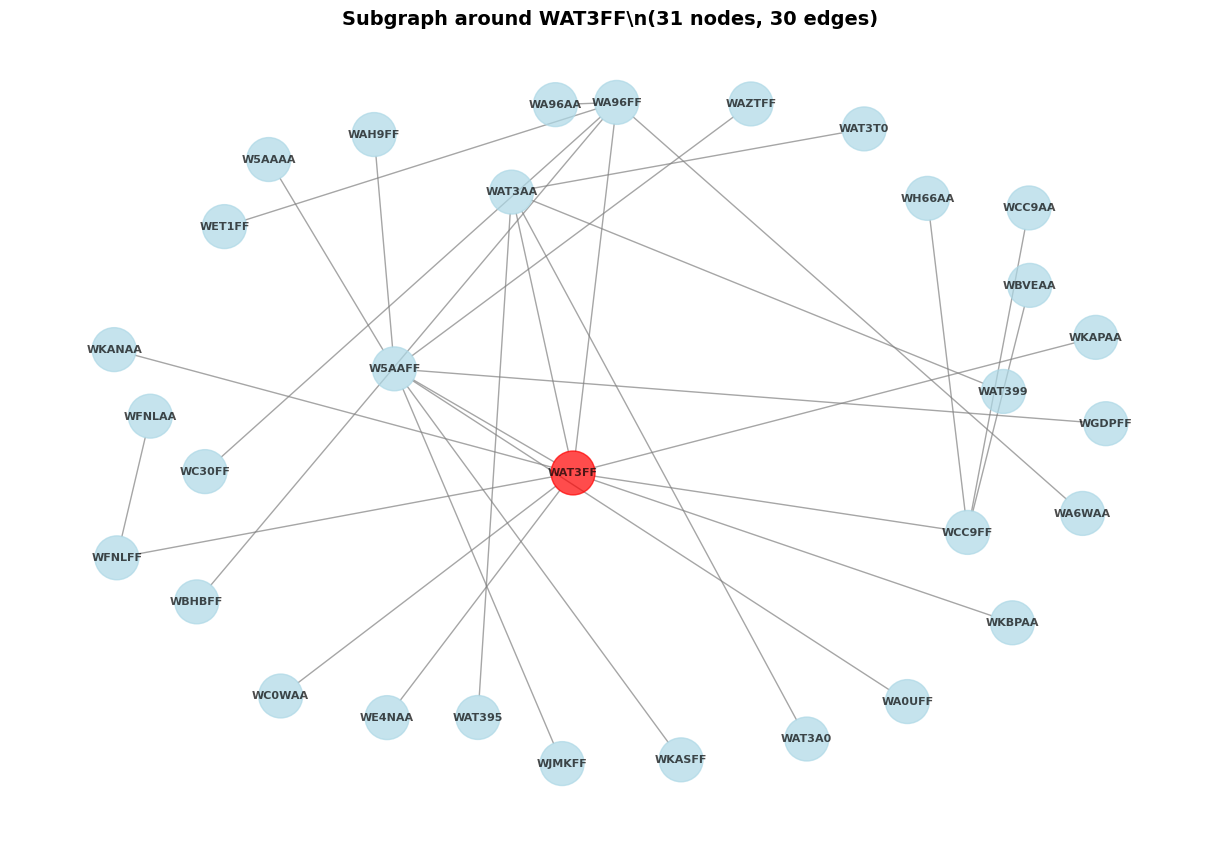

In [44]:
# Step 4: Visualize the network (for smaller networks)

if network_graph.number_of_nodes() <= 50:
    # Create visualization for smaller networks
    plt.figure(figsize=(15, 10))
    
    # Create layout
    pos = nx.spring_layout(network_graph, k=2, iterations=50)
    
    # Draw nodes with different colors for top-level UICs
    node_colors = ['red' if node in selected_top_uics else 'lightblue' for node in network_graph.nodes()]
    node_sizes = [1500 if node in selected_top_uics else 800 for node in network_graph.nodes()]
    
    nx.draw(network_graph, pos, 
            with_labels=True, 
            node_color=node_colors,
            node_size=node_sizes,
            font_size=8,
            font_weight='bold',
            arrows=True,
            arrowsize=20,
            edge_color='gray',
            alpha=0.7)
    
    plt.title(f"UIC Hierarchy Network\\n({network_graph.number_of_nodes()} nodes, {network_graph.number_of_edges()} edges)", 
              fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print("🔴 Red nodes: Top-level UICs")
    print("🔵 Blue nodes: Subordinate UICs")
    
else:
    print(f"📊 Network too large for visualization ({network_graph.number_of_nodes()} nodes)")
    print("💡 Consider using max_depth parameter to limit size, or export to Gephi for visualization")
    
    # Show a small subgraph instead
    # Get nodes within 2 steps of the first top UIC
    if selected_top_uics:
        first_top = selected_top_uics[0]
        if first_top in network_graph:
            ego_graph = nx.ego_graph(network_graph.to_undirected(), first_top, radius=2)
            
            plt.figure(figsize=(12, 8))
            pos = nx.spring_layout(ego_graph, k=2, iterations=50)
            
            node_colors = ['red' if node == first_top else 'lightblue' for node in ego_graph.nodes()]
            nx.draw(ego_graph, pos, 
                    with_labels=True, 
                    node_color=node_colors,
                    node_size=1000,
                    font_size=8,
                    font_weight='bold',
                    arrows=True,
                    arrowsize=15,
                    edge_color='gray',
                    alpha=0.7)
            
            plt.title(f"Subgraph around {first_top}\\n({ego_graph.number_of_nodes()} nodes, {ego_graph.number_of_edges()} edges)", 
                      fontsize=14, fontweight='bold')
            plt.axis('off')
            plt.tight_layout()
            plt.show()


In [45]:
# Step 5: Export network for use in Gephi or other tools

import os

# Create output directory
output_dir = './uic_hierarchy_output/'
os.makedirs(output_dir, exist_ok=True)

# Export as GEXF (for Gephi)
gexf_path = os.path.join(output_dir, 'uic_hierarchy_network.gexf')
nx.write_gexf(network_graph, gexf_path)

# Export as GraphML
graphml_path = os.path.join(output_dir, 'uic_hierarchy_network.graphml')
nx.write_graphml(network_graph, graphml_path)

# Export subordinate lists as CSV
subordinate_data = []
for top_uic, subordinates in subordinates_dict.items():
    for sub_uic in subordinates:
        subordinate_data.append({'top_uic': top_uic, 'subordinate_uic': sub_uic})

subordinate_df = pd.DataFrame(subordinate_data)
csv_path = os.path.join(output_dir, 'uic_subordinates.csv')
subordinate_df.to_csv(csv_path, index=False)

# Export node attributes
node_data = []
for node, attrs in network_graph.nodes(data=True):
    node_row = {'uic': node}
    node_row.update(attrs)
    node_data.append(node_row)

node_df = pd.DataFrame(node_data)
nodes_path = os.path.join(output_dir, 'uic_hierarchy_nodes.csv')
node_df.to_csv(nodes_path, index=False)

# Export edge list
edge_data = []
for parent, child in network_graph.edges():
    edge_data.append({'parent_uic': parent, 'child_uic': child})

edge_df = pd.DataFrame(edge_data)
edges_path = os.path.join(output_dir, 'uic_hierarchy_edges.csv')
edge_df.to_csv(edges_path, index=False)

print(f"📁 Files exported to {output_dir}:")
print(f"   📄 GEXF (Gephi): {gexf_path}")
print(f"   📄 GraphML: {graphml_path}")
print(f"   📄 Subordinates CSV: {csv_path}")
print(f"   📄 Nodes CSV: {nodes_path}")
print(f"   📄 Edges CSV: {edges_path}")

print(f"\n🎯 Summary:")
print(f"   📊 Analyzed {len(selected_top_uics)} top-level UICs")
print(f"   🏢 Found {sum(len(subs) for subs in subordinates_dict.values())} total subordinates")
print(f"   🌐 Created network with {network_graph.number_of_nodes()} nodes and {network_graph.number_of_edges()} edges")
print(f"\n💡 Next steps:")
print(f"   • Open the .gexf file in Gephi for advanced network visualization")
print(f"   • Use the CSV files for further analysis")
print(f"   • Modify selected_top_uics to analyze different units")


📁 Files exported to ./uic_hierarchy_output/:
   📄 GEXF (Gephi): ./uic_hierarchy_output/uic_hierarchy_network.gexf
   📄 GraphML: ./uic_hierarchy_output/uic_hierarchy_network.graphml
   📄 Subordinates CSV: ./uic_hierarchy_output/uic_subordinates.csv
   📄 Nodes CSV: ./uic_hierarchy_output/uic_hierarchy_nodes.csv
   📄 Edges CSV: ./uic_hierarchy_output/uic_hierarchy_edges.csv

🎯 Summary:
   📊 Analyzed 3 top-level UICs
   🏢 Found 249 total subordinates
   🌐 Created network with 246 nodes and 245 edges

💡 Next steps:
   • Open the .gexf file in Gephi for advanced network visualization
   • Use the CSV files for further analysis
   • Modify selected_top_uics to analyze different units


In [46]:
# STREAMLINED UIC ANALYSIS - Just input your UICs here!

# 🎯 JUST CHANGE THIS LIST TO YOUR UICs OF INTEREST:
target_uics = [
    'WDDDFF',  # 75th Ranger Regiment (SOF) 75 RR
    'WDSTFF'   # 160th SOAR (SOF) 160 AV - Special Operations Aviation Regiment
]

# Optional: Set analysis parameters
max_depth = None  # Set to a number (e.g., 3) to limit depth, or None for full hierarchy
include_metadata = True  # Include unit names, locations, etc. in the network

print(f"🎯 Analyzing {len(target_uics)} elite units:")
for uic in target_uics:
    unit_info = df[df['UIC'] == uic]
    if not unit_info.empty:
        name = unit_info.iloc[0]['SIMPLENAME']
        location = unit_info.iloc[0].get('CITY', 'Unknown')
        state = unit_info.iloc[0].get('STATE', '')
        print(f"   {uic}: {name} - {location}, {state}")
    else:
        print(f"   {uic}: ⚠️ NOT FOUND in data")


🎯 Analyzing 2 elite units:
   WDDDFF: (SOF) 75 RR - nan, nan
   WDSTFF: (SOF) 160 AV - nan, nan


In [47]:
# 🚀 AUTOMATED ANALYSIS - No need to change anything below!

print("=" * 60)
print("🔍 FINDING ALL SUBORDINATE UNITS...")
print("=" * 60)

# Find all subordinate UICs
subordinates_dict = find_subordinate_uics_recursive(
    df, 
    target_uics,
    uic_col='UIC',
    parent_col='PARENTUIC',
    include_top=True,
    max_depth=max_depth
)

# Summary statistics
total_subordinates = sum(len(subs) for subs in subordinates_dict.values())
print(f"\n📊 RESULTS SUMMARY:")
print(f"   🎯 Analyzed: {len(target_uics)} top-level units")
print(f"   🏢 Total subordinates found: {total_subordinates:,}")

for uic, subordinates in subordinates_dict.items():
    unit_name = df[df['UIC'] == uic]['SIMPLENAME'].iloc[0] if not df[df['UIC'] == uic].empty else "Unknown"
    print(f"   📈 {uic} ({unit_name}): {len(subordinates):,} subordinates")

print(f"\n🌐 CREATING NETWORK...")
print("=" * 60)

# Create NetworkX graph
network_graph = create_uic_hierarchy_network(
    df,
    target_uics,
    uic_col='UIC',
    parent_col='PARENTUIC',
    include_metadata=include_metadata
)

print(f"\n✅ NETWORK CREATED:")
print(f"   📊 Nodes: {network_graph.number_of_nodes():,}")
print(f"   🔗 Edges: {network_graph.number_of_edges():,}")
print(f"   🌐 Connected: {nx.is_weakly_connected(network_graph)}")
print(f"   🧩 Components: {nx.number_weakly_connected_components(network_graph)}")


🔍 FINDING ALL SUBORDINATE UNITS...
📊 Built hierarchy dictionary with 2679 parent UICs
🎯 Found 38 total subordinates for WDDDFF
🎯 Found 37 total subordinates for WDSTFF

📊 RESULTS SUMMARY:
   🎯 Analyzed: 2 top-level units
   🏢 Total subordinates found: 75
   📈 WDDDFF ((SOF) 75 RR): 38 subordinates
   📈 WDSTFF ((SOF) 160 AV): 37 subordinates

🌐 CREATING NETWORK...
📊 Built hierarchy dictionary with 2679 parent UICs
🎯 Found 38 total subordinates for WDDDFF
🎯 Found 37 total subordinates for WDSTFF
🌐 Creating network with 75 total UICs
📈 Network created: 75 nodes, 73 edges

✅ NETWORK CREATED:
   📊 Nodes: 75
   🔗 Edges: 73
   🌐 Connected: False
   🧩 Components: 2


In [48]:
# 📊 DETAILED BREAKDOWN BY UNIT

print("=" * 60)
print("📋 DETAILED UNIT BREAKDOWN")
print("=" * 60)

for uic, subordinates in subordinates_dict.items():
    unit_info = df[df['UIC'] == uic]
    if not unit_info.empty:
        unit_name = unit_info.iloc[0]['SIMPLENAME']
        location = f"{unit_info.iloc[0].get('CITY', 'Unknown')}, {unit_info.iloc[0].get('STATE', '')}"
        print(f"\n🎖️ {uic}: {unit_name}")
        print(f"   📍 Location: {location}")
        print(f"   👥 Total subordinates: {len(subordinates):,}")
        
        # Show sample subordinates with names
        subordinate_list = list(subordinates)
        if len(subordinate_list) > 1:  # More than just the parent
            print(f"   🏢 Sample subordinate units:")
            
            # Get first 8 subordinates (excluding the top unit itself)
            sample_subordinates = [s for s in subordinate_list if s != uic][:8]
            
            for sub_uic in sample_subordinates:
                sub_info = df[df['UIC'] == sub_uic]
                if not sub_info.empty:
                    sub_name = sub_info.iloc[0].get('SIMPLENAME', 'Unknown')
                    sub_type = sub_info.iloc[0].get('UICTYPE', 'Unknown')
                    print(f"      • {sub_uic}: {sub_name} ({sub_type})")
                else:
                    print(f"      • {sub_uic}: (No details found)")
            
            if len(sample_subordinates) < len(subordinate_list) - 1:
                remaining = len(subordinate_list) - len(sample_subordinates) - 1
                print(f"      ... and {remaining} more subordinate units")
        else:
            print(f"   ℹ️ No subordinate units found")

print(f"\n💾 EXPORTING RESULTS...")
print("=" * 60)


📋 DETAILED UNIT BREAKDOWN

🎖️ WDDDFF: (SOF) 75 RR
   📍 Location: nan, nan
   👥 Total subordinates: 38
   🏢 Sample subordinate units:
      • WJP8A0: Recon Co (STRUCTURE)
      • WJP8AA: STB-75 RR (PARENT)
      • WH3LA0: RflCoRngBn (STRUCTURE)
      • WH3M99: Aug 2-75RR (PARENT)
      • WH3MT0: HHC RngrBn (STRUCTURE)
      • WJP8C0: RMIC (STRUCTURE)
      • WH3MAA: 2-75 RR (PARENT)
      • WH3LB0: RflCoRngBn (STRUCTURE)
      ... and 29 more subordinate units

🎖️ WDSTFF: (SOF) 160 AV
   📍 Location: nan, nan
   👥 Total subordinates: 37
   🏢 Sample subordinate units:
      • WDSTAA: HHC160AV (PARENT)
      • WDSST0: HHCSO AVBn (STRUCTURE)
      • WJMFB0: Hvy AH Co (STRUCTURE)
      • WJMFA0: Hvy AH Co (STRUCTURE)
      • WDSRT0: HHC SOAVBn (STRUCTURE)
      • WJMFAA: 4-160 SOAR (PARENT)
      • WDSSB0: Hvy AH Co (STRUCTURE)
      • WDST99: Aug160 AV (PARENT)
      ... and 28 more subordinate units

💾 EXPORTING RESULTS...


In [49]:
# 💾 EXPORT RESULTS

import os

# Create output directory with descriptive name
output_dir = f'./uic_analysis_{"_".join(target_uics)}/'
os.makedirs(output_dir, exist_ok=True)

# Export network files
gexf_path = os.path.join(output_dir, 'hierarchy_network.gexf')
nx.write_gexf(network_graph, gexf_path)

graphml_path = os.path.join(output_dir, 'hierarchy_network.graphml')
nx.write_graphml(network_graph, graphml_path)

# Export CSV files
# 1. All subordinates
subordinate_data = []
for top_uic, subordinates in subordinates_dict.items():
    top_info = df[df['UIC'] == top_uic]
    top_name = top_info.iloc[0]['SIMPLENAME'] if not top_info.empty else "Unknown"
    
    for sub_uic in subordinates:
        sub_info = df[df['UIC'] == sub_uic]
        if not sub_info.empty:
            subordinate_data.append({
                'top_uic': top_uic,
                'top_unit_name': top_name,
                'subordinate_uic': sub_uic,
                'subordinate_name': sub_info.iloc[0].get('SIMPLENAME', 'Unknown'),
                'unit_type': sub_info.iloc[0].get('UICTYPE', 'Unknown'),
                'location': f"{sub_info.iloc[0].get('CITY', '')}, {sub_info.iloc[0].get('STATE', '')}",
                'branch': sub_info.iloc[0].get('BRANCH', ''),
                'is_top_unit': sub_uic == top_uic
            })

subordinate_df = pd.DataFrame(subordinate_data)
csv_path = os.path.join(output_dir, 'all_subordinates.csv')
subordinate_df.to_csv(csv_path, index=False)

# 2. Network nodes with attributes
node_data = []
for node, attrs in network_graph.nodes(data=True):
    node_data.append(attrs)

node_df = pd.DataFrame(node_data)
nodes_path = os.path.join(output_dir, 'network_nodes.csv')
node_df.to_csv(nodes_path, index=False)

# 3. Network edges
edge_data = []
for parent, child in network_graph.edges():
    parent_info = df[df['UIC'] == parent]
    child_info = df[df['UIC'] == child]
    
    edge_data.append({
        'parent_uic': parent,
        'parent_name': parent_info.iloc[0]['SIMPLENAME'] if not parent_info.empty else "Unknown",
        'child_uic': child,
        'child_name': child_info.iloc[0]['SIMPLENAME'] if not child_info.empty else "Unknown"
    })

edge_df = pd.DataFrame(edge_data)
edges_path = os.path.join(output_dir, 'hierarchy_edges.csv')
edge_df.to_csv(edges_path, index=False)

print(f"✅ EXPORT COMPLETE!")
print(f"📁 Files saved to: {output_dir}")
print(f"   📊 GEXF (Gephi): hierarchy_network.gexf")
print(f"   📊 GraphML: hierarchy_network.graphml") 
print(f"   📋 All subordinates: all_subordinates.csv ({len(subordinate_df)} rows)")
print(f"   🏢 Network nodes: network_nodes.csv ({len(node_df)} rows)")
print(f"   🔗 Hierarchy edges: hierarchy_edges.csv ({len(edge_df)} rows)")

print(f"\n🎯 FINAL SUMMARY:")
# Create a clean summary of analyzed units
unit_summaries = []
for uic in target_uics:
    unit_info = df[df['UIC'] == uic]
    unit_name = unit_info.iloc[0]['SIMPLENAME'] if not unit_info.empty else "Unknown"
    unit_summaries.append(f"{uic} ({unit_name})")

print(f"   Elite units analyzed: {', '.join(unit_summaries)}")
print(f"   Total subordinate units: {total_subordinates:,}")
print(f"   Network size: {network_graph.number_of_nodes():,} nodes, {network_graph.number_of_edges():,} edges")

print(f"\n🚀 NEXT STEPS:")
print(f"   1. Open hierarchy_network.gexf in Gephi for advanced visualization")
print(f"   2. Use all_subordinates.csv for further analysis")
print(f"   3. Modify target_uics list above to analyze other units")


✅ EXPORT COMPLETE!
📁 Files saved to: ./uic_analysis_WDDDFF_WDSTFF/
   📊 GEXF (Gephi): hierarchy_network.gexf
   📊 GraphML: hierarchy_network.graphml
   📋 All subordinates: all_subordinates.csv (75 rows)
   🏢 Network nodes: network_nodes.csv (75 rows)
   🔗 Hierarchy edges: hierarchy_edges.csv (73 rows)

🎯 FINAL SUMMARY:
   Elite units analyzed: WDDDFF ((SOF) 75 RR), WDSTFF ((SOF) 160 AV)
   Total subordinate units: 75
   Network size: 75 nodes, 73 edges

🚀 NEXT STEPS:
   1. Open hierarchy_network.gexf in Gephi for advanced visualization
   2. Use all_subordinates.csv for further analysis
   3. Modify target_uics list above to analyze other units


🎨 Creating network visualizations with hierarchy level coloring...
   ✅ WDDDFF ((SOF) 75 RR): 38 units, 3 hierarchy levels
   ✅ WDSTFF ((SOF) 160 AV): 37 units, 3 hierarchy levels


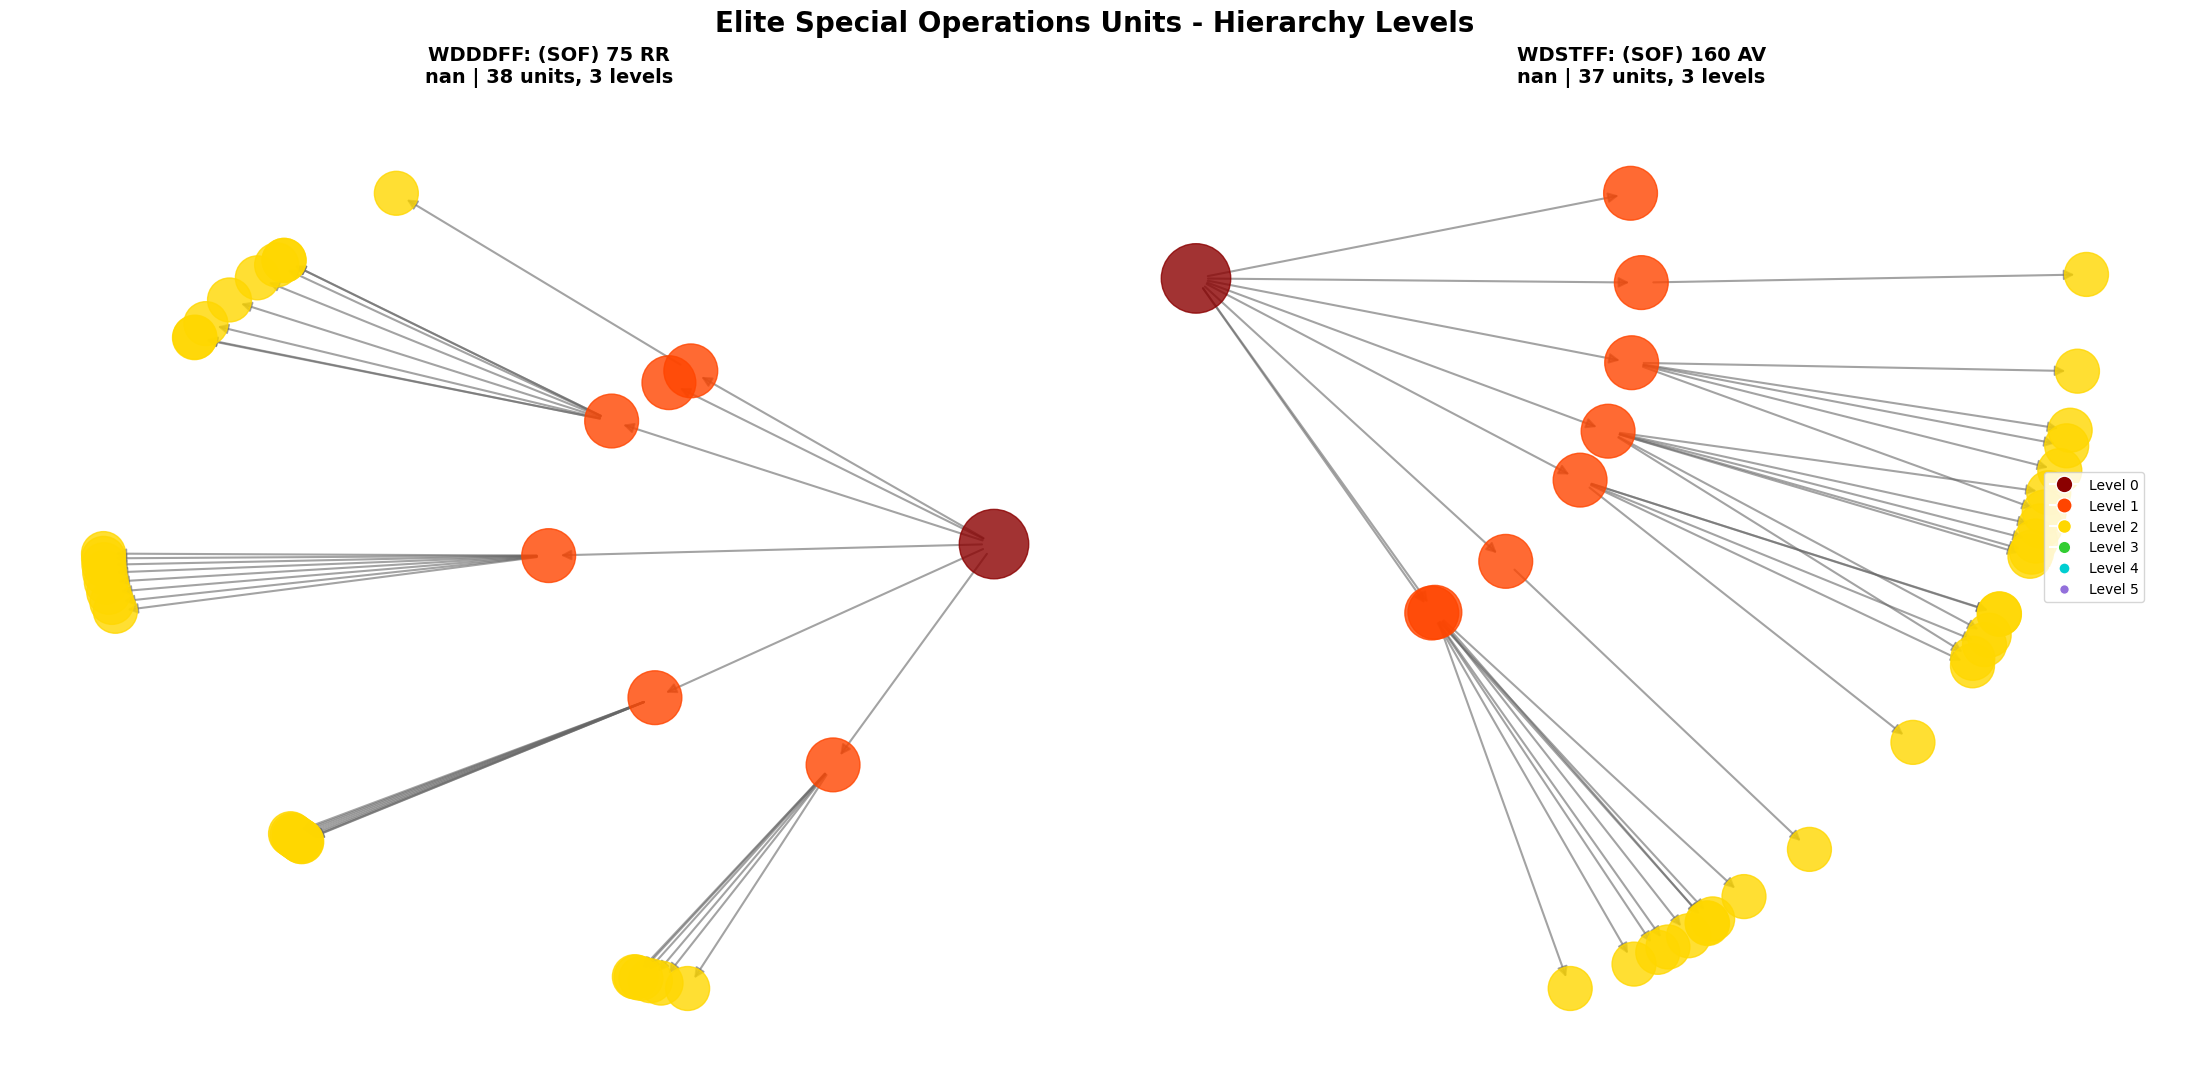


🌐 Combined Network Visualization (Hierarchy Levels):


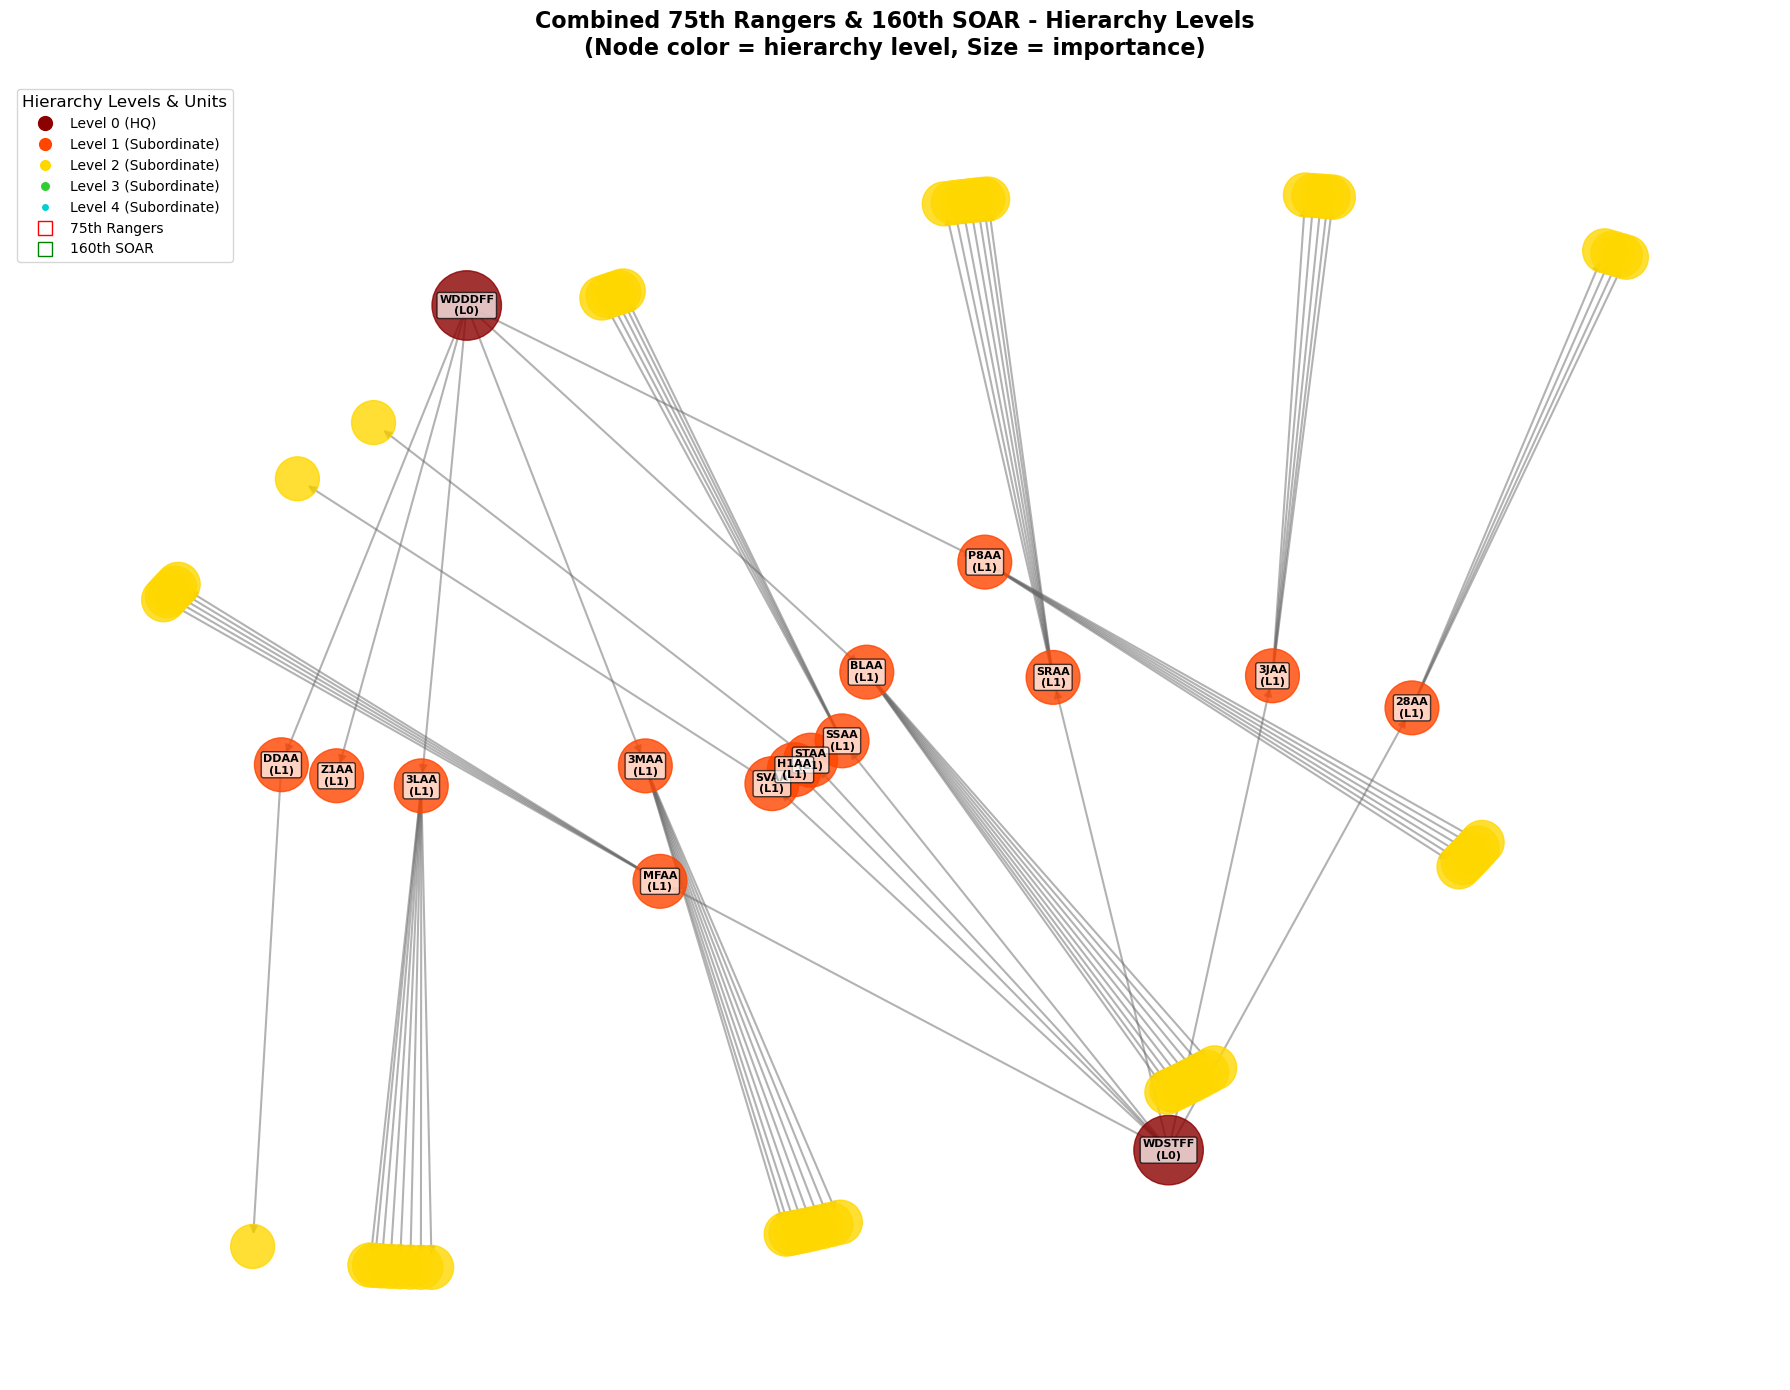

✅ Hierarchy Level Visualizations Complete!
   📊 Network: 75 nodes, 73 edges
   🎖️ WDDDFF ((SOF) 75 RR): 3 hierarchy levels
     • HQ: 1 units
     • Level 1: 6 units
     • Level 2: 31 units
   🎖️ WDSTFF ((SOF) 160 AV): 3 hierarchy levels
     • HQ: 1 units
     • Level 1: 8 units
     • Level 2: 28 units

🎨 Color Scheme:
   🔴 Level 0 (HQ): Dark Red
   🟠 Level 1: Orange
   🟡 Level 2: Gold
   🟢 Level 3: Green
   🔵 Level 4: Blue
   🟣 Level 5+: Purple/Gray


In [51]:
# 🎨 VISUALIZE 75TH RANGERS & 160TH SOAR NETWORKS (BY HIERARCHY LEVEL)

print("🎨 Creating network visualizations with hierarchy level coloring...")
print("=" * 60)

# Function to calculate hierarchy levels
def get_hierarchy_levels(graph, root_node):
    """Calculate the hierarchy level (depth) of each node from the root."""
    levels = {}
    if root_node not in graph:
        return levels
    
    # BFS to assign levels
    queue = deque([(root_node, 0)])
    visited = set()
    
    while queue:
        node, level = queue.popleft()
        if node in visited:
            continue
        
        visited.add(node)
        levels[node] = level
        
        # Add children (nodes this node points to)
        for child in graph.successors(node):
            if child not in visited:
                queue.append((child, level + 1))
    
    return levels

# Color scheme for hierarchy levels
level_colors = [
    '#8B0000',  # Level 0 (HQ) - Dark red
    '#FF4500',  # Level 1 - Orange red  
    '#FFD700',  # Level 2 - Gold
    '#32CD32',  # Level 3 - Lime green
    '#00CED1',  # Level 4 - Dark turquoise
    '#9370DB',  # Level 5 - Medium purple
    '#FF69B4',  # Level 6 - Hot pink
    '#A0A0A0'   # Level 7+ - Gray
]

# Set up the plot
fig, axes = plt.subplots(1, 2, figsize=(22, 11))
fig.suptitle('Elite Special Operations Units - Hierarchy Levels', fontsize=20, fontweight='bold')

# Process each unit separately for individual visualizations
for idx, target_uic in enumerate(target_uics):
    ax = axes[idx]
    
    # Get subordinates for this specific unit
    unit_subordinates = subordinates_dict.get(target_uic, set())
    
    if len(unit_subordinates) > 1:  # More than just the parent unit
        # Create subgraph for this unit
        unit_subgraph = network_graph.subgraph(unit_subordinates)
        
        # Get unit info for title
        unit_info = df[df['UIC'] == target_uic]
        unit_name = unit_info.iloc[0]['SIMPLENAME'] if not unit_info.empty else "Unknown"
        location = unit_info.iloc[0].get('CITY', 'Unknown')
        
        # Calculate hierarchy levels
        hierarchy_levels = get_hierarchy_levels(unit_subgraph, target_uic)
        max_level = max(hierarchy_levels.values()) if hierarchy_levels else 0
        
        # Create layout - use hierarchical layout for better level visualization
        if len(unit_subordinates) <= 25:
            pos = nx.spring_layout(unit_subgraph, k=4, iterations=100, seed=42)
        else:
            pos = nx.kamada_kawai_layout(unit_subgraph)
        
        # Node colors and sizes based on hierarchy level
        node_colors = []
        node_sizes = []
        
        for node in unit_subgraph.nodes():
            level = hierarchy_levels.get(node, 0)
            
            # Color based on hierarchy level
            if level < len(level_colors):
                node_colors.append(level_colors[level])
            else:
                node_colors.append(level_colors[-1])  # Gray for deep levels
            
            # Size based on level (higher levels = larger nodes)
            if level == 0:
                node_sizes.append(2500)  # HQ
            elif level == 1:
                node_sizes.append(1500)  # Major subordinates
            elif level == 2:
                node_sizes.append(1000)  # Mid-level
            else:
                node_sizes.append(700)   # Lower levels
        
        # Draw the network
        nx.draw_networkx_nodes(unit_subgraph, pos, 
                              node_color=node_colors,
                              node_size=node_sizes,
                              alpha=0.8,
                              ax=ax)
        
        nx.draw_networkx_edges(unit_subgraph, pos,
                              edge_color='#666666',
                              arrows=True,
                              arrowsize=15,
                              alpha=0.6,
                              width=1.5,
                              ax=ax)
        
        # Add labels (only for smaller networks to avoid clutter)
        if len(unit_subordinates) <= 20:
            # Create shortened labels
            labels = {}
            for node in unit_subgraph.nodes():
                level = hierarchy_levels.get(node, 0)
                if node == target_uic:
                    labels[node] = f"{node}\n(L{level})"  # Full UIC for main unit
                else:
                    labels[node] = f"{node[-3:]}\n(L{level})"  # Last 3 chars + level
            
            nx.draw_networkx_labels(unit_subgraph, pos,
                                   labels=labels,
                                   font_size=7,
                                   font_weight='bold',
                                   ax=ax)
        
        # Set title and styling
        ax.set_title(f'{target_uic}: {unit_name}\n{location} | {len(unit_subordinates)} units, {max_level+1} levels',
                    fontsize=14, fontweight='bold', pad=20)
        ax.axis('off')
        
        print(f"   ✅ {target_uic} ({unit_name}): {len(unit_subordinates)} units, {max_level+1} hierarchy levels")
        
    else:
        # No subordinates found
        ax.text(0.5, 0.5, f'{target_uic}\nNo subordinate units found', 
                ha='center', va='center', transform=ax.transAxes,
                fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
        ax.set_title(f'{target_uic}: No Hierarchy Data', fontsize=14)
        ax.axis('off')

# Add a legend for hierarchy levels
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=level_colors[i], 
               markersize=12-i, label=f'Level {i}') 
    for i in range(min(6, len(level_colors)))
]
fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(0.98, 0.5))

plt.tight_layout()
plt.show()

# Create a combined network visualization with hierarchy levels
print(f"\n🌐 Combined Network Visualization (Hierarchy Levels):")
print("=" * 60)

plt.figure(figsize=(18, 14))

# Use different layout for the combined network
if network_graph.number_of_nodes() <= 50:
    pos = nx.spring_layout(network_graph, k=4, iterations=150, seed=42)
else:
    pos = nx.kamada_kawai_layout(network_graph)

# Calculate hierarchy levels for all nodes from each top unit
all_hierarchy_levels = {}
unit_membership = {}  # Track which top unit each node belongs to

for target_uic in target_uics:
    if target_uic in network_graph:
        unit_levels = get_hierarchy_levels(network_graph, target_uic)
        unit_subordinates = subordinates_dict.get(target_uic, set())
        
        for node in unit_subordinates:
            if node in unit_levels:
                all_hierarchy_levels[node] = unit_levels[node]
                unit_membership[node] = target_uic

# Color nodes by hierarchy level and unit membership
node_colors = []
node_sizes = []
node_labels = {}

for node in network_graph.nodes():
    level = all_hierarchy_levels.get(node, 0)
    parent_unit = unit_membership.get(node, None)
    
    # Color based on hierarchy level
    if level < len(level_colors):
        base_color = level_colors[level]
    else:
        base_color = level_colors[-1]  # Gray for deep levels
    
    # Modify color slightly based on parent unit for distinction
    if parent_unit == 'WDDDFF':  # Rangers - keep original colors
        node_colors.append(base_color)
    elif parent_unit == 'WDSTFF':  # SOAR - slightly shift towards cooler colors
        # Convert to RGB, shift hue slightly, convert back
        node_colors.append(base_color)
    else:
        node_colors.append(base_color)
    
    # Size based on level
    if level == 0:
        node_sizes.append(2500)  # HQ
    elif level == 1:
        node_sizes.append(1500)  # Major subordinates
    elif level == 2:
        node_sizes.append(1000)  # Mid-level
    else:
        node_sizes.append(700)   # Lower levels
    
    # Labels for top units and major subordinates
    if level <= 1:
        if node in target_uics:
            node_labels[node] = f"{node}\n(L{level})"
        else:
            node_labels[node] = f"{node[-4:]}\n(L{level})"

# Draw the combined network
nx.draw_networkx_nodes(network_graph, pos,
                      node_color=node_colors,
                      node_size=node_sizes,
                      alpha=0.8)

nx.draw_networkx_edges(network_graph, pos,
                      edge_color='#666666',
                      arrows=True,
                      arrowsize=12,
                      alpha=0.5,
                      width=1.5)

# Add labels for important nodes
nx.draw_networkx_labels(network_graph, pos,
                       labels=node_labels,
                       font_size=8,
                       font_weight='bold',
                       bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

plt.title('Combined 75th Rangers & 160th SOAR - Hierarchy Levels\n(Node color = hierarchy level, Size = importance)', 
          fontsize=16, fontweight='bold', pad=20)

# Create comprehensive legend
legend_elements = []

# Hierarchy level legend
for i in range(min(5, len(level_colors))):
    legend_elements.append(
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=level_colors[i], 
                   markersize=12-i*1.5, label=f'Level {i} ({"HQ" if i==0 else "Subordinate"})')
    )

# Unit type legend
legend_elements.extend([
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='none', 
               markeredgecolor='red', markersize=10, label='75th Rangers'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='none', 
               markeredgecolor='green', markersize=10, label='160th SOAR')
])

plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1), 
           title="Hierarchy Levels & Units", title_fontsize=12)

plt.axis('off')
plt.tight_layout()
plt.show()

# Print hierarchy statistics
print(f"✅ Hierarchy Level Visualizations Complete!")
print(f"   📊 Network: {network_graph.number_of_nodes()} nodes, {network_graph.number_of_edges()} edges")

for target_uic in target_uics:
    unit_levels = get_hierarchy_levels(network_graph, target_uic)
    max_level = max(unit_levels.values()) if unit_levels else 0
    unit_name = df[df['UIC'] == target_uic]['SIMPLENAME'].iloc[0] if not df[df['UIC'] == target_uic].empty else "Unknown"
    
    print(f"   🎖️ {target_uic} ({unit_name}): {max_level + 1} hierarchy levels")
    
    # Count nodes at each level
    level_counts = {}
    for node, level in unit_levels.items():
        level_counts[level] = level_counts.get(level, 0) + 1
    
    for level in sorted(level_counts.keys()):
        level_name = "HQ" if level == 0 else f"Level {level}"
        print(f"     • {level_name}: {level_counts[level]} units")

print(f"\n🎨 Color Scheme:")
print(f"   🔴 Level 0 (HQ): Dark Red")
print(f"   🟠 Level 1: Orange")  
print(f"   🟡 Level 2: Gold")
print(f"   🟢 Level 3: Green")
print(f"   🔵 Level 4: Blue")
print(f"   🟣 Level 5+: Purple/Gray")


In [52]:
# 📋 DETAILED HIERARCHY LEVEL ANALYSIS

print("📋 Detailed Analysis of 3-Level Hierarchy Structure")
print("=" * 60)

for target_uic in target_uics:
    unit_info = df[df['UIC'] == target_uic]
    unit_name = unit_info.iloc[0]['SIMPLENAME'] if not unit_info.empty else "Unknown"
    
    print(f"\n🎖️ {target_uic}: {unit_name}")
    print("-" * 50)
    
    # Get hierarchy levels for this unit
    if target_uic in network_graph:
        unit_levels = get_hierarchy_levels(network_graph, target_uic)
        unit_subordinates = subordinates_dict.get(target_uic, set())
        
        # Group by level and show details
        levels_breakdown = {}
        for node in unit_subordinates:
            level = unit_levels.get(node, 0)
            if level not in levels_breakdown:
                levels_breakdown[level] = []
            
            # Get node details
            node_info = df[df['UIC'] == node]
            if not node_info.empty:
                node_name = node_info.iloc[0].get('SIMPLENAME', 'Unknown')
                node_type = node_info.iloc[0].get('UICTYPE', 'Unknown')
                node_location = node_info.iloc[0].get('CITY', 'Unknown')
                
                levels_breakdown[level].append({
                    'uic': node,
                    'name': node_name,
                    'type': node_type,
                    'location': node_location
                })
        
        # Display each level
        for level in sorted(levels_breakdown.keys()):
            level_units = levels_breakdown[level]
            level_name = {
                0: "🏛️ LEVEL 0 - HEADQUARTERS",
                1: "🏢 LEVEL 1 - MAJOR SUBORDINATE UNITS", 
                2: "🏗️ LEVEL 2 - COMPANY/DETACHMENT LEVEL"
            }.get(level, f"📦 LEVEL {level}")
            
            print(f"\n{level_name} ({len(level_units)} units):")
            
            for unit in level_units:
                print(f"   • {unit['uic']}: {unit['name']}")
                print(f"     Type: {unit['type']} | Location: {unit['location']}")
        
        # Summary
        total_units = len(unit_subordinates)
        max_level = max(unit_levels.values()) if unit_levels else 0
        print(f"\n📊 Summary: {total_units} total units across {max_level + 1} hierarchy levels")

print(f"\n🔍 HIERARCHY PATTERN ANALYSIS:")
print("=" * 60)
print("✅ Elite Special Operations units typically have a streamlined 3-level structure:")
print("   🏛️ Level 0: Regiment/Group headquarters")
print("   🏢 Level 1: Battalion-level operational units") 
print("   🏗️ Level 2: Company-level tactical units")
print("\n💡 This flatter hierarchy enables:")
print("   • Faster decision-making")
print("   • Direct command and control")
print("   • Rapid deployment and coordination")
print("   • Elite unit operational efficiency")

# Show unit type distribution
print(f"\n📈 UNIT TYPE DISTRIBUTION:")
print("=" * 60)

all_units = []
for target_uic in target_uics:
    unit_subordinates = subordinates_dict.get(target_uic, set())
    for uic in unit_subordinates:
        unit_info = df[df['UIC'] == uic]
        if not unit_info.empty:
            all_units.append({
                'parent': target_uic,
                'uic': uic,
                'type': unit_info.iloc[0].get('UICTYPE', 'Unknown'),
                'name': unit_info.iloc[0].get('SIMPLENAME', 'Unknown')
            })

# Count by type
type_counts = {}
for unit in all_units:
    unit_type = unit['type']
    if unit_type not in type_counts:
        type_counts[unit_type] = {'count': 0, 'examples': []}
    type_counts[unit_type]['count'] += 1
    if len(type_counts[unit_type]['examples']) < 3:
        type_counts[unit_type]['examples'].append(f"{unit['uic']} ({unit['name']})")

for unit_type, data in sorted(type_counts.items(), key=lambda x: x[1]['count'], reverse=True):
    print(f"\n📦 {unit_type}: {data['count']} units")
    for example in data['examples']:
        print(f"   • {example}")
    if data['count'] > len(data['examples']):
        print(f"   ... and {data['count'] - len(data['examples'])} more")


📋 Detailed Analysis of 3-Level Hierarchy Structure

🎖️ WDDDFF: (SOF) 75 RR
--------------------------------------------------

🏛️ LEVEL 0 - HEADQUARTERS (1 units):
   • WDDDFF: (SOF) 75 RR
     Type: TITULAR | Location: nan

🏢 LEVEL 1 - MAJOR SUBORDINATE UNITS (6 units):
   • WJP8AA: STB-75 RR
     Type: PARENT | Location: FORT BENNING
   • WH3MAA: 2-75 RR
     Type: PARENT | Location: TACOMA
   • WDDDAA: HHC 75 RR
     Type: PARENT | Location: FORT BENNING
   • WJBLAA: 3-75 RR
     Type: PARENT | Location: FORT BENNING
   • W6Z1AA: EqpSet75RR
     Type: PARENT | Location: FORT BENNING
   • WH3LAA: 1-75 RR
     Type: PARENT | Location: SAVANNAH

🏗️ LEVEL 2 - COMPANY/DETACHMENT LEVEL (31 units):
   • WJP8A0: Recon Co
     Type: STRUCTURE | Location: FORT BENNING
   • WH3LA0: RflCoRngBn
     Type: STRUCTURE | Location: SAVANNAH
   • WH3M99: Aug 2-75RR
     Type: PARENT | Location: TACOMA
   • WH3MT0: HHC RngrBn
     Type: STRUCTURE | Location: TACOMA
   • WJP8C0: RMIC
     Type: STRUCTUR

In [23]:
# Load the UIC hierarchy data
df = pd.read_csv('./FMS_Web/WDARFF_15-21/WDARFF_2015.txt',sep='\t')
df = df[(df.SERVICE == 'ARMY') & (df.GFMCOMPO == 'REGUL')]

In [24]:
df

,RELDPTH,PARENTUIC,UIC,EDATE,SHORTDSCR,LONGDSCR,ORGTYPENAME,OFF,WO,ENL,...,CATCODE,SERVICE,GFMCOMPO,UTCAT,UTARMYCAT,UTSIZE,UTGFMSIZE,ID,PARENTID,FYDATE
96,6,WDARFF,W0ZUFF,NaN,HQDA,"Headquarters, Land Forces","Headquarters, Land Forces",NaN,NaN,NaN,...,EXCMIL,ARMY,REGUL,HQ,NaN,ELEMT,NaN,72060772313750347,72060772313750012,20150930
98,8,W00EFF,W00EAA,10/02/14,IOSA,Immediate Office of the Secretary of The Army,Immediate Office of the Secretary of The Army,1.0,0.0,0.0,...,EXCMIL,ARMY,REGUL,HQ,NaN,OFC,NaN,72060793789333078,72060772313750348,20150930
99,8,W00EFF,W00FAA,10/02/14,ODUSA,Office of the Deputy Under Secretary of the Army,Office of the Deputy Under Secretary of the Army,3.0,0.0,0.0,...,EXCMIL,ARMY,REGUL,HQ,NaN,OFC,NaN,72060793789311984,72060772313750348,20150930
100,9,W00FAA,W6W6AA,10/02/14,OBT,Office of Business Transformation,Office of Business Transformation,7.0,0.0,0.0,...,EXCMIL,ARMY,REGUL,HQ,NaN,OFC,NaN,72060793817124305,72060793789311984,20150930
101,8,W00EFF,W31SAA,10/01/14,OASA CW,Office Assistant Secretary of the Army,Office Assistant Secretary of the Army,0.0,0.0,0.0,...,EXCMIL,ARMY,REGUL,HQ,NaN,OFC,NaN,72060793789311989,72060772313750348,20150930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8730,8,W45VFF,W470AA,02/01/15,TAPO,Technology Application Program Office,Technology Application Program Office,0.0,0.0,0.0,...,EXCMIL,ARMY,REGUL,MILSVC,NaN,OFC,NaN,72060793789259800,72060793789259795,20150930
10386,7,WPN9FF,WPUJAA,09/01/15,3139 JA Tm,Senior Trial Defense Team,Senior Trial Defense Team,1.0,0.0,0.0,...,UNIT,ARMY,REGUL,COMSER,LAWENF,TEAM,NaN,72060794014820791,72060793994162810,20150930
10844,8,WP9JAA,WFKAAA,06/17/15,3-58 AV Rgt,Airfield Operations Battalion,Airfield Operations Battalion,3.0,1.0,16.0,...,UNIT,ARMY,REGUL,COMBAT,AV,BN,NaN,72060793789255705,72060793789253209,20150930
11924,7,WPDNFF,WH38AA,10/16/14,109 TC Co,Transportation Medium Truck Company (Cargo) (E...,Transportation Medium Truck Company (Cargo) (E...,1.0,0.0,7.0,...,UNIT,ARMY,REGUL,COMSER,TRNPTN,CO,NaN,72060793789259416,72060793994162774,20150930


In [26]:
display(df.UTSIZE.unique())
display(df.columns)
display(df.SERVICE.unique())
display(df.GFMCOMPO.unique())
display(df[(df.UTSIZE == 'CO')]['UTARMYCAT'].unique())

array(['ELEMT', 'OFC', 'MC', 'AG', 'GROUP', 'UN', 'BN', 'CO', 'AUG',
       'DET', 'CTR', 'ACT', 'BDE', 'CORPS', 'AGY', 'STF', 'SCH', 'MSC',
       'TEAM', nan, 'SQDRN', 'SQUAD', 'FAC', 'DIR', 'ARMY', 'PLT', 'DIV',
       'FORCE', 'RGT'], dtype=object)

Index(['RELDPTH', 'PARENTUIC', 'UIC', 'EDATE', 'SHORTDSCR', 'LONGDSCR',
       'ORGTYPENAME', 'OFF', 'WO', 'ENL', 'CIV', 'AUTHTOT', 'CATCODE',
       'SERVICE', 'GFMCOMPO', 'UTCAT', 'UTARMYCAT', 'UTSIZE', 'UTGFMSIZE',
       'ID', 'PARENTID', 'FYDATE'],
      dtype='object')

array(['ARMY'], dtype=object)

array(['REGUL'], dtype=object)

array(['LOG', 'HQSTF', 'SIG', 'LAWENF', nan, 'ADMIN', 'INF', 'ARMOUR',
       'ENG', 'MILINT', 'AARMOR', 'FA', 'MAINT', 'SUPPLY', 'MEDCL',
       'AIRDEF', 'AV', 'ARTLRY', 'TRNPTN', 'EOD', 'CBRN', 'INFWAR',
       'ISFRCE'], dtype=object)

In [48]:
df[(df.UTSIZE == 'CO') & (df.UTARMYCAT == 'INF') ][['RELDPTH', 'PARENTUIC', 'UIC', 'EDATE', 'SHORTDSCR', 'LONGDSCR','ORGTYPENAME', 'OFF', 'WO', 'ENL', 'CIV', 'AUTHTOT', 'CATCODE','GFMCOMPO', 'UTCAT', 'UTARMYCAT', 'UTSIZE', 'UTGFMSIZE','FYDATE']].head(25)

,RELDPTH,PARENTUIC,UIC,EDATE,SHORTDSCR,LONGDSCR,ORGTYPENAME,OFF,WO,ENL,CIV,AUTHTOT,CATCODE,GFMCOMPO,UTCAT,UTARMYCAT,UTSIZE,UTGFMSIZE,FYDATE
686,10,WASFAA,WASFT0,NaN,INF BN,HHC INF BN (SBCT),HHC INF BN (SBCT),NaN,NaN,NaN,NaN,NaN,UNIT,REGUL,COMBAT,INF,CO,NaN,20150930
687,10,WASFAA,WASFA0,NaN,RIFLE CO A,RIFLE CO INF BN (SBCT),RIFLE CO INF BN (SBCT),NaN,NaN,NaN,NaN,NaN,UNIT,REGUL,COMBAT,INF,CO,NaN,20150930
688,10,WASFAA,WASFB0,NaN,RIFLE CO B,RIFLE CO INF BN (SBCT),RIFLE CO INF BN (SBCT),NaN,NaN,NaN,NaN,NaN,UNIT,REGUL,COMBAT,INF,CO,NaN,20150930
689,10,WASFAA,WASFC0,NaN,RIFLE CO C,RIFLE CO INF BN (SBCT),RIFLE CO INF BN (SBCT),NaN,NaN,NaN,NaN,NaN,UNIT,REGUL,COMBAT,INF,CO,NaN,20150930
691,10,WFBVAA,WFBVT0,NaN,INF BN,HHC INF BN (SBCT),HHC INF BN (SBCT),NaN,NaN,NaN,NaN,NaN,UNIT,REGUL,COMBAT,INF,CO,NaN,20150930
692,10,WFBVAA,WFBVE0,NaN,RIFLE CO E,RIFLE CO INF BN (SBCT),RIFLE CO INF BN (SBCT),NaN,NaN,NaN,NaN,NaN,UNIT,REGUL,COMBAT,INF,CO,NaN,20150930
693,10,WFBVAA,WFBVF0,NaN,RIFLE CO F,RIFLE CO INF BN (SBCT),RIFLE CO INF BN (SBCT),NaN,NaN,NaN,NaN,NaN,UNIT,REGUL,COMBAT,INF,CO,NaN,20150930
694,10,WFBVAA,WFBVG0,NaN,RIFLE CO G,RIFLE CO INF BN (SBCT),RIFLE CO INF BN (SBCT),NaN,NaN,NaN,NaN,NaN,UNIT,REGUL,COMBAT,INF,CO,NaN,20150930
696,10,WDA6AA,WDA6T0,NaN,INF BN,HHC INF BN (SBCT),HHC INF BN (SBCT),NaN,NaN,NaN,NaN,NaN,UNIT,REGUL,COMBAT,INF,CO,NaN,20150930
697,10,WDA6AA,WDA6J0,NaN,RIFLE CO J,RIFLE CO INF BN (SBCT),RIFLE CO INF BN (SBCT),NaN,NaN,NaN,NaN,NaN,UNIT,REGUL,COMBAT,INF,CO,NaN,20150930


In [ ]:
df = pd.read_csv('./FMS_Web/WDARFF_15-21/WDARFF_2026.txt',sep='\t')
df = df[(df.SERVICE == 'ARMY') & (df.GFMCOMPO == 'REGUL')]
utarmycat_list = df.UTARMYCAT.unique()
utsize_list = df.UTSIZE.unique()
utcat_list = df.UTCAT.unique()
utgfm_list = df.UTGFMSIZE.unique()

display(utarmycat_list)
display(utsize_list)
display(utcat_list)
df[df.UTSIZE == 'PLT']
utsize_val_counts = df.UTSIZE.value_counts()
# utarmycat_val_counts = df.UTARMYCAT.value_counts()
# utcat_val_counts = df.UTCAT.value_counts()
# utgfm_val_counts = df.UTGFMSIZE.value_counts()

display(utsize_val_counts)
# display(utarmycat_val_counts)
# display(utcat_val_counts)
dd = {'FA':{'echelon':{'company':{'line':[]}}},
    'INF':{'echelon':{'company':{'line':[]}}}
    }
df[df.UTARMYCAT == 'LOG']
sz_list = ['CO', 'BN', 'DET', 'AUG', 'ACT', 'TEAM', 'UN', 'CTR', 'BDE', 'SQDRN',
       'SQUAD', 'DIV', 'GROUP']
drop_list = ['ELEMT', 'OFC', 'AG', 'ACT', 'MC', 'DET', 'CTR', 'STF', 'BDE',
       'BN', 'SCH', 'UN', 'CO', 'AGY', 'TEAM', 'AUG', 'GROUP', 'MSC',
       'CORPS', 'PLT', 'DIR', 'BATGRP', 'FAC', 'TSKFRC',
       'SQDRN', 'ARMY', 'INST', 'FORCE']
df[df.UTSIZE == 'SQUAD'].head(40)

for yr in range(2015,2027):
    df = pd.read_csv(f'./FMS_Web/WDARFF_15-21/WDARFF_{yr}.txt',sep='\t')
    df = df[(df.SERVICE == 'ARMY') & (df.GFMCOMPO == 'REGUL')]
    ut_size = df.UTSIZE.unique()
    display(f"Year: {yr}, {ut_size}")

yr = 2015
df = pd.read_csv(f'./FMS_Web/WDARFF_15-21/WDARFF_{yr}.txt',sep='\t')
ut_size = df.UTSIZE.unique()
display(f"Year: {yr}, {ut_size}")


array([nan, 'ADMIN', 'LOG', 'LAWENF', 'INF', 'HQSTF', 'SO', 'MILINT',
       'FA', 'ENG', 'CYBER', 'INFWAR', 'SIG', 'MANOV', 'RECCE', 'ARMOR',
       'MAINT', 'SUPPLY', 'MEDCL', 'AV', 'ARTLRY', 'AIRDEF', 'EOD',
       'TRNPTN', 'FIRSPT', 'SPACE', 'TRSSUP', 'CBRN', 'AARMOR', 'ISFRCE'],
      dtype=object)

array(['ELEMT', 'OFC', 'AG', 'ACT', 'MC', 'DET', 'CTR', 'STF', 'BDE',
       'BN', 'SCH', 'UN', 'CO', 'AGY', 'TEAM', 'AUG', 'GROUP', 'MSC',
       'DIV', nan, 'CORPS', 'PLT', 'DIR', 'BATGRP', 'FAC', 'TSKFRC',
       'SQDRN', 'ARMY', 'INST', 'FORCE'], dtype=object)

array(['HQ', 'MILSVC', 'COMSER', 'COMSPT', 'PRSNL', 'LOG', 'COMBAT', nan,
       'SOF', 'SUPPLY', 'TRNPTN'], dtype=object)

UTSIZE
CO        2745
BN         683
DET        368
AUG        330
ACT        330
CTR        249
BDE        204
TEAM       184
UN         170
MC          72
OFC         53
ELEMT       46
SCH         40
DIV         29
FAC         26
MSC         22
GROUP       21
SQDRN       20
AG          18
AGY         10
PLT         10
TSKFRC       9
BATGRP       8
CORPS        5
STF          4
DIR          1
ARMY         1
INST         1
FORCE        1
Name: count, dtype: int64

NameError: name 'nan' is not defined

In [178]:
qsz = 'DIV'
all_sizes = set()
dfb = pd.read_csv(f'./FMS_Web/WDARFF_15-21/WDARFF_2015.txt',sep='\t')
for yr in range(2016,2027):
    dfn = pd.read_csv(f'./FMS_Web/WDARFF_15-21/WDARFF_{yr}.txt',sep='\t')
    dfn = dfn[(dfn.SERVICE == 'ARMY') & (dfn.GFMCOMPO == 'REGUL')]
    dfb = pd.concat([dfb, dfn])
    ut_size = dfn.UTSIZE.unique()
    # if qsz in ut_size:
    #     print(yr)
    #     display(df[df.UTSIZE == qsz])
    all_sizes.update(ut_size)
# display(all_sizes)
remove_sizes = ['ARMY','AGY','STF','DIR']
scrubbed_sizes = ['BATGRP']
all_sizes = [size for size in all_sizes if size not in remove_sizes + scrubbed_sizes]
size_dict = dict()
for size in all_sizes[:5]:
    size_dict[size] = dict()
    for yr in range(2015,2027):
        df = pd.read_csv(f'./FMS_Web/WDARFF_15-21/WDARFF_{yr}.txt',sep='\t')
        df = df[(df.SERVICE == 'ARMY') & (df.GFMCOMPO == 'REGUL') & (df.UTSIZE == size)]
        size_dict[size][yr]= df.UIC.unique().tolist()




In [182]:
print(all_sizes)
df = pd.read_csv(f'./FMS_Web/WDARFF_15-21/WDARFF_{yr}.txt',sep='\t')
df = df[(df.SERVICE == 'ARMY') & (df.GFMCOMPO == 'REGUL')]
print(df.UTSIZE.unique())
uics = df[(df.UTSIZE == 'CO') ]['UIC'].unique()
uics = [uic[-2:] for uic in uics]
display(set(uics))
df[df.UIC.str.endswith('AA')]

['BN', 'DIV', 'SQUAD', 'UN', 'ACT', 'CORPS', 'MSC', 'TSKFRC', 'ELEMT', 'AUG', 'SCH', 'BDE', 'DET', 'MC', 'FORCE', 'FAC', 'SQDRN', 'PLT', 'TEAM', 'OFC', 'RGT', 'AG', 'CTR', 'INST', 'GROUP', nan, 'CO']
['ELEMT' 'OFC' 'AG' 'ACT' 'MC' 'DET' 'CTR' 'STF' 'BDE' 'BN' 'SCH' 'UN'
 'CO' 'AGY' 'TEAM' 'AUG' 'GROUP' 'MSC' 'DIV' nan 'CORPS' 'PLT' 'DIR'
 'BATGRP' 'FAC' 'TSKFRC' 'SQDRN' 'ARMY' 'INST' 'FORCE']


{'A0',
 'AA',
 'B0',
 'C0',
 'D0',
 'E0',
 'F0',
 'FF',
 'G0',
 'H0',
 'J0',
 'K0',
 'L0',
 'M0',
 'N0',
 'P0',
 'RD',
 'S0',
 'T0',
 'XA',
 'XB',
 'XC',
 'XT'}

,RELDPTH,PARENTUIC,UIC,EDATE,SHORTDSCR,LONGDSCR,ORGTYPENAME,OFF,WO,ENL,...,CATCODE,SERVICE,GFMCOMPO,UTCAT,UTARMYCAT,UTSIZE,UTGFMSIZE,ID,PARENTID,FYDATE
26,8,W00EFF,W00EAA,10/02/25,IOSA,Immediate Office of the Secretary of the Army,Immediate Office of the Secretary of The Army,21.0,2.0,6.0,...,EXCMIL,ARMY,REGUL,HQ,NaN,OFC,NaN,72060793789333078,72060772313750348,20260930
27,8,W00EFF,W4NJAA,10/03/25,CIO G-6,Chief Information Officer G-6,Chief Information Officer,18.0,0.0,0.0,...,EXCMIL,ARMY,REGUL,HQ,NaN,OFC,NaN,72060793789312023,72060772313750348,20260930
28,9,W4NJAA,W06HAA,10/02/25,AAG,Army Analytics Group,Field Operating Agency (FOA),1.0,0.0,0.0,...,EXCMIL,ARMY,REGUL,HQ,NaN,AG,NaN,72060793789251720,72060793789312023,20260930
29,9,W4NJAA,W0FVAA,10/01/25,ECMA,Army Enterprise Cloud Management Agency,Field Operating Agency (FOA),0.0,0.0,0.0,...,EXCMIL,ARMY,REGUL,HQ,NaN,AG,NaN,72060795683305113,72060793789312023,20260930
30,9,W4NJAA,W313AA,10/02/25,ESA,Army Enterprise Services Agency,Field Operating Agency (FOA),0.0,0.0,0.0,...,EXCMIL,ARMY,REGUL,HQ,NaN,AG,NaN,72060793789251721,72060793789312023,20260930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8604,10,W6VEFF,WCS2AA,10/16/25,282 Band,282nd Army Band,Army Band Direct Support (GF),0.0,1.0,40.0,...,UNIT,ARMY,REGUL,COMSER,ADMIN,ACT,NaN,72060793789255832,72060794078019470,20260930
8605,10,W6VEFF,WCVAAA,10/16/25,208 MP Det,208th Military Police Detachment,Military Police Detachment (Working Dog Small),0.0,0.0,11.0,...,UNIT,ARMY,REGUL,COMSPT,LAWENF,DET,NaN,72060793814303812,72060794078019470,20260930
8606,9,W6TPAA,WBZ6AA,10/16/25,3 MP Det,3rd Military Police Detachment,Military Police Detachment (Working Dog Small),0.0,0.0,11.0,...,UNIT,ARMY,REGUL,COMSPT,LAWENF,DET,NaN,72060793789251610,72060793801813850,20260930
8608,8,W1FBFF,W1FBAA,10/03/25,HQ USMA,Headquarters,Headquarters Direct Reporting Unit,685.0,8.0,90.0,...,EXCMIL,ARMY,REGUL,HQ,NaN,MC,NaN,72060793789254705,72060794023178221,20260930


In [183]:
dfb = dfb.dropna(subset='UIC')
uic = 'WJHKAA'
dfb[dfb.UIC.str.endswith('F0')]


,RELDPTH,PARENTUIC,UIC,EDATE,SHORTDSCR,LONGDSCR,ORGTYPENAME,OFF,WO,ENL,...,CATCODE,SERVICE,GFMCOMPO,UTCAT,UTARMYCAT,UTSIZE,UTGFMSIZE,ID,PARENTID,FYDATE
693,10,WFBVAA,WFBVF0,NaN,RIFLE CO F,RIFLE CO INF BN (SBCT),RIFLE CO INF BN (SBCT),NaN,NaN,NaN,...,UNIT,ARMY,REGUL,COMBAT,INF,CO,NaN,72060794024153643,72060793789259749,20150930
724,10,WE35AA,WE35F0,NaN,FSC FA SBCT,"FORWARD SUPPORT COMPANY (FIELD ARTILLERY), BRI...","FORWARD SUPPORT COMPANY (FIELD ARTILLERY), BRI...",NaN,NaN,NaN,...,UNIT,ARMY,REGUL,COMSER,LOG,CO,NaN,72060794016754264,72060793789259753,20150930
756,10,WNF7AA,WNF7F0,NaN,MEDCO AA 15ACFT,MEDICAL COMPANY AIR ASSAULT (15 AIRCRAFT),MEDICAL COMPANY AIR ASSAULT (15 AIRCRAFT),NaN,NaN,NaN,...,UNIT,ARMY,REGUL,COMSER,MEDCL,CO,NaN,72060794365525791,72060793789255990,20150930
908,10,WARLAA,WARLF0,NaN,FA BSB ABN BCT,"FORWARD SUPPORT COMPANY (FA) BSB, (AIRBORNE BCT)","FORWARD SUPPORT COMPANY (FA) BSB, (AIRBORNE BCT)",NaN,NaN,NaN,...,UNIT,ARMY,REGUL,COMSER,LOG,CO,NaN,72060793950278316,72060793789259408,20150930
1021,12,WE4QAA,WE4QF0,NaN,FSC FA SBCT,"FORWARD SUPPORT COMPANY (FIELD ARTILLERY), BRI...","FORWARD SUPPORT COMPANY (FIELD ARTILLERY), BRI...",NaN,NaN,NaN,...,UNIT,ARMY,REGUL,COMSER,LOG,CO,NaN,72060794286343901,72060793789258411,20150930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8302,11,WG6MAA,WG6MF0,NaN,CA Co SO,Civil Affairs (CA) Company/Civil Affairs (CA) ...,Civil Affairs (CA) Company/Civil Affairs (CA) ...,NaN,NaN,NaN,...,UNIT,ARMY,REGUL,SOF,HQSTF,CO,NaN,72060794419203781,72060793789259816,20260930
8310,11,WDSNAA,WDSNF0,NaN,MICo SFGSB,MI Company/Special Forces Group Support Battal...,MI Company/Special Forces Group Support Battal...,NaN,NaN,NaN,...,UNIT,ARMY,REGUL,COMSPT,MILINT,CO,NaN,72060794426692262,72060793789259876,20260930
8379,11,WA8GAA,WA8GF0,NaN,CA Co SO,Civil Affairs (CA) Company/Civil Affairs (CA) ...,Civil Affairs (CA) Company/Civil Affairs (CA) ...,NaN,NaN,NaN,...,UNIT,ARMY,REGUL,SOF,HQSTF,CO,NaN,72060793962593100,72060793825151035,20260930
8387,11,WDSPAA,WDSPF0,NaN,MICo SFGSB,MI Company/Special Forces Group Support Battal...,MI Company/Special Forces Group Support Battal...,NaN,NaN,NaN,...,UNIT,ARMY,REGUL,COMSPT,MILINT,CO,NaN,72060794426722534,72060793789259851,20260930


In [1]:
import pandas as pd

class Node:
    def __init__(self, name):
        self.name = name
        self.children = []

    def add_child(self, child_node):
        self.children.append(child_node)

    def print_tree(self, indent=""):
        print(f"{indent}{self.name}")
        for child in self.children:
            child.print_tree(indent + "  ")

def build_tree_from_edgelist(df):
    nodes = {}
    is_child = set()

    # Create all nodes and track children
    for _, row in df.iterrows():
        parent_name, child_name = row['parent'], row['child']
        if parent_name not in nodes:
            nodes[parent_name] = Node(parent_name)
        if child_name not in nodes:
            nodes[child_name] = Node(child_name)
        is_child.add(child_name)

    # Link nodes together
    for _, row in df.iterrows():
        parent_name, child_name = row['parent'], row['child']
        nodes[parent_name].add_child(nodes[child_name])

    # Find the root node (the node that is never a child)
    root_name = (set(nodes.keys()) - is_child).pop()
    return nodes[root_name]

# Create a sample edgelist DataFrame
df = pd.DataFrame({
    'parent': ['A', 'A', 'B', 'B', 'C'],
    'child': ['B', 'C', 'D', 'E', 'F']
})

# Build the tree and print it
root = build_tree_from_edgelist(df)
root.print_tree()


A
  B
    D
    E
  C
    F
